In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
%matplotlib inline

print("✅ Libraries have downloaded!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")

✅ Libraries have downloaded!
📊 Pandas version: 2.3.3
🔢 NumPy version: 2.2.6


In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"📊 Total of {len(df):,} customer data ")
print(f"📋 {len(df.columns)} column\n")

df.head()

📊 Total of 7,043 customer data 
📋 21 column



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Data info:")
print("="*60)
df.info()

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

CHURN distribution:

No:  5,174 müşteri (73.5%)
Yes: 1,869 müşteri (26.5%)


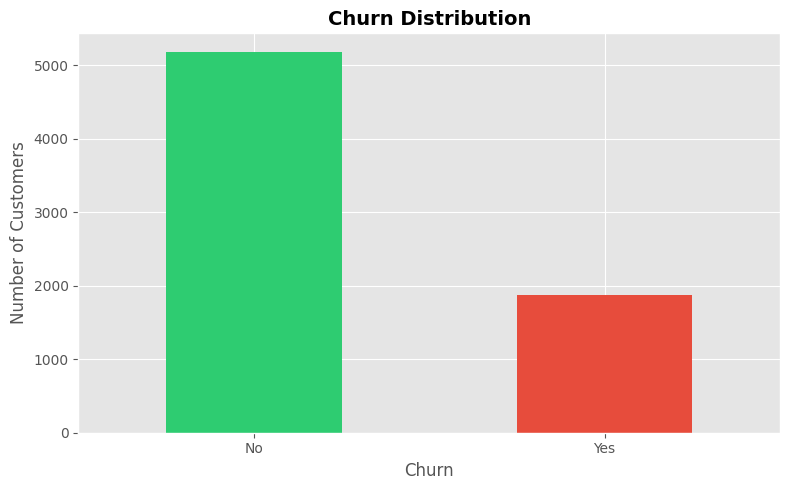

In [8]:
print("CHURN distribution:")
print("="*60)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"\nNo:  {churn_counts['No']:,} müşteri ({churn_pct['No']:.1f}%)")
print(f"Yes: {churn_counts['Yes']:,} müşteri ({churn_pct['Yes']:.1f}%)")

# Görselleştir
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(" Financial Impact Analysis")
print("="*60)

churned = df[df['Churn'] == 'Yes']

monthly_revenue_loss = churned['MonthlyCharges'].sum()
print(f"\n Monthly Revenue Loss: ${monthly_revenue_loss:,.2f}")

annual_revenue_loss = monthly_revenue_loss * 12
print(f" Annual Revenue Loss: ${annual_revenue_loss:,.2f}")

avg_customer_value = churned['TotalCharges'].mean()
print(f"\n Average Customer Loss: ${avg_customer_value:,.2f}")

total_loss = churned['TotalCharges'].sum()
print(f" Total Customer Loss: ${total_loss:,.2f}")

 Financial Impact Analysis

 Monthly Revenue Loss: $139,130.85
 Annual Revenue Loss: $1,669,570.20

 Average Customer Loss: $1,531.80
 Total Customer Loss: $2,862,926.90


CONTRACT TYPE ANALYSIS

 Customer Distribution by Contract Type:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

 Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


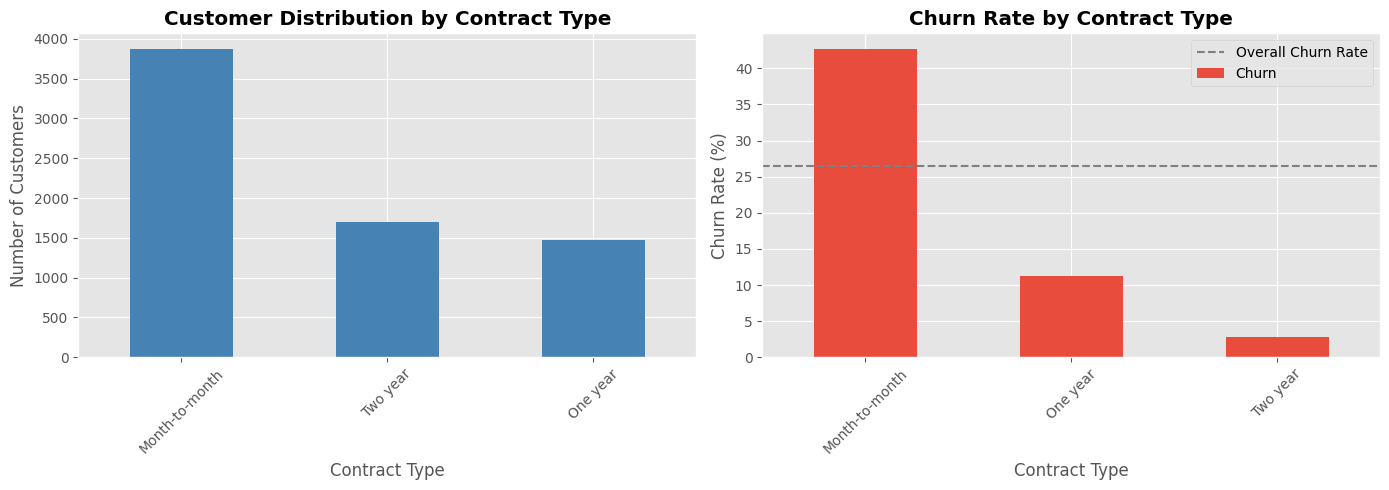

In [10]:
print("CONTRACT TYPE ANALYSIS")
print("="*60)

print("\n Customer Distribution by Contract Type:")
print(df['Contract'].value_counts())

print("\n Churn Rate by Contract Type:")
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print(contract_churn.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df['Contract'].value_counts().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Customer Distribution by Contract Type', fontweight='bold')
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Contract Type')
ax1.tick_params(axis='x', rotation=45)

contract_churn.plot(kind='bar', ax=ax2, color='#e74c3c')
ax2.set_title('Churn Rate by Contract Type', fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_xlabel('Contract Type')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=26.5, color='gray', linestyle='--', label='Overall Churn Rate')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
print("REVENUE LOSS BY CONTRACT TYPE")
print("="*60)

churned_by_contract = df[df['Churn'] == 'Yes'].groupby('Contract').agg({
    'customerID': 'count',
    'MonthlyCharges': 'sum',
    'TotalCharges': 'sum'
}).round(2)

churned_by_contract.columns = ['Churned Customers', 'Monthly Revenue Loss', 'Total Revenue Loss']

churned_by_contract['Annual Revenue Loss'] = churned_by_contract['Monthly Revenue Loss'] * 12

print("\n Contract Type Breakdown:")
print(churned_by_contract)

print("\n" + "="*60)
print("HIGHEST RISK SEGMENT:")
print("="*60)

month_to_month_loss = churned_by_contract.loc['Month-to-month', 'Annual Revenue Loss']
month_to_month_customers = churned_by_contract.loc['Month-to-month', 'Churned Customers']

print(f" Month-to-month customers")
print(f"   → {month_to_month_customers:,.0f} customers lost")
print(f"   → ${month_to_month_loss:,.2f} annual revenue loss")
print(f"   → {(month_to_month_customers/1869)*100:.1f}% of total churn")

REVENUE LOSS BY CONTRACT TYPE

 Contract Type Breakdown:
                Churned Customers  Monthly Revenue Loss  Total Revenue Loss  \
Contract                                                                      
Month-to-month               1655             120847.10          1927182.25   
One year                      166              14118.45           674991.20   
Two year                       48               4165.30           260753.45   

                Annual Revenue Loss  
Contract                             
Month-to-month            1450165.2  
One year                   169421.4  
Two year                    49983.6  

HIGHEST RISK SEGMENT:
 Month-to-month customers
   → 1,655 customers lost
   → $1,450,165.20 annual revenue loss
   → 88.6% of total churn


In [12]:
print(" BUSINESS RECOMMENDATION")
print("="*60)

# Scenario: Convert 30% of month-to-month customers to 1-year contract
target_customers = int(month_to_month_customers * 0.30)
avg_monthly_charge = df[df['Contract'] == 'Month-to-month']['MonthlyCharges'].mean()

# Retention improvement (assumption: 1-year contract has much lower churn)
current_mtm_churn_rate = contract_churn['Month-to-month']
one_year_churn_rate = contract_churn['One year']
churn_reduction = current_mtm_churn_rate - one_year_churn_rate

# Potential savings
potential_annual_savings = (target_customers * avg_monthly_charge * 12 * (churn_reduction / 100))

print(f"\n ACTION PLAN:")
print(f"   Target: {target_customers:,} month-to-month customers")
print(f"   Migrate to 1-year contract")
print(f"\n EXPECTED IMPACT:")
print(f"   → Churn rate reduction: {churn_reduction:.1f}%")
print(f"   → Potential annual savings: ${potential_annual_savings:,.2f}")
print(f"   → ROI: Depends on marketing campaign cost")

print(f"\n RECOMMENDATIONS:")
print(f"   1. Offer 15-20% discount for 1-year contract")
print(f"   2. Launch targeted email campaign to month-to-month customers")
print(f"   3. Start pilot program with first 500 customers")
print(f"   4. Measure results after 3 months")

 BUSINESS RECOMMENDATION

 ACTION PLAN:
   Target: 496 month-to-month customers
   Migrate to 1-year contract

 EXPECTED IMPACT:
   → Churn rate reduction: 31.4%
   → Potential annual savings: $124,252.71
   → ROI: Depends on marketing campaign cost

 RECOMMENDATIONS:
   1. Offer 15-20% discount for 1-year contract
   2. Launch targeted email campaign to month-to-month customers
   3. Start pilot program with first 500 customers
   4. Measure results after 3 months


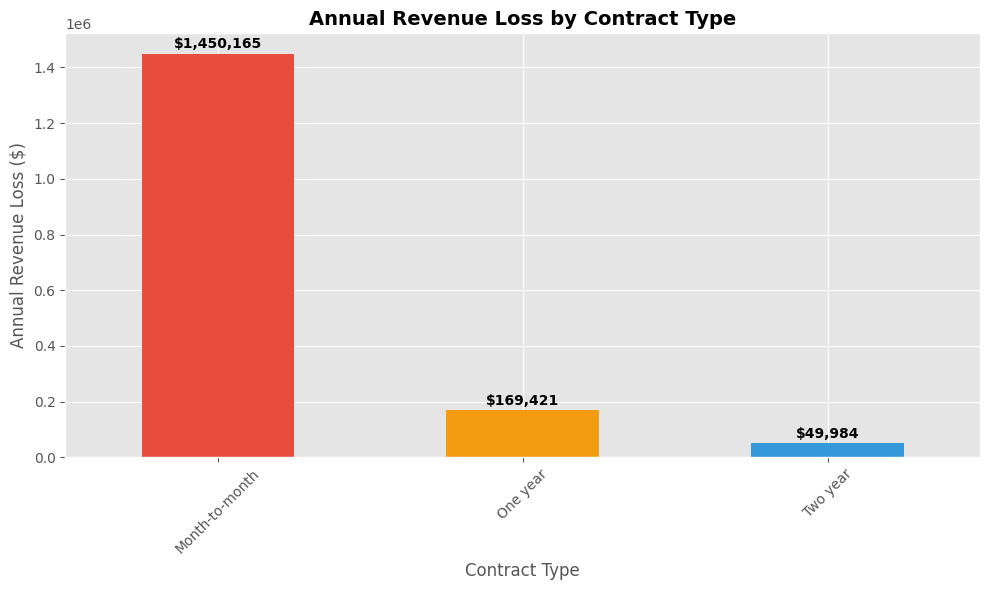

In [13]:
# Revenue loss visualization
plt.figure(figsize=(10, 6))
churned_by_contract['Annual Revenue Loss'].plot(
    kind='bar', 
    color=['#e74c3c', '#f39c12', '#3498db']
)
plt.title('Annual Revenue Loss by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Annual Revenue Loss ($)')
plt.xlabel('Contract Type')
plt.xticks(rotation=45)

# Add values on top of bars
for i, v in enumerate(churned_by_contract['Annual Revenue Loss']):
    plt.text(i, v + 20000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

 TENURE ANALYSIS

Tenure Statistics:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

 Churn Rate by Tenure Group:
tenure_group
0-12 months     47.68
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64


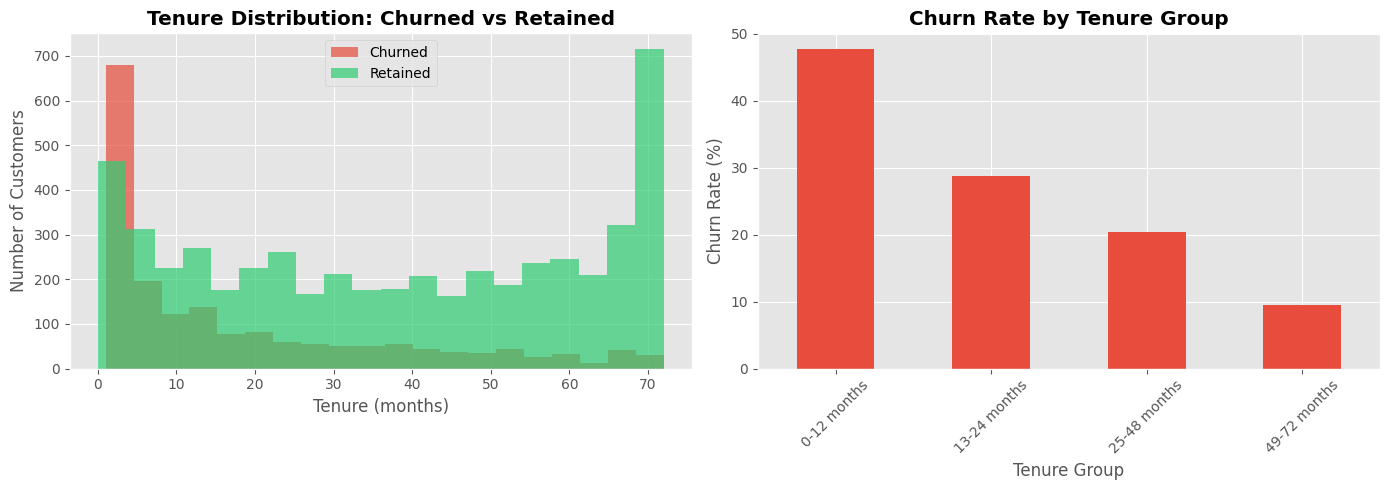

In [14]:
print(" TENURE ANALYSIS")
print("="*60)

# Tenure distribution
print("\nTenure Statistics:")
print(df['tenure'].describe())

# Churn by tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])

tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)

print("\n Churn Rate by Tenure Group:")
print(tenure_churn.round(2))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tenure distribution for churned vs retained
df[df['Churn'] == 'Yes']['tenure'].hist(bins=20, ax=ax1, color='#e74c3c', alpha=0.7, label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(bins=20, ax=ax1, color='#2ecc71', alpha=0.7, label='Retained')
ax1.set_title('Tenure Distribution: Churned vs Retained', fontweight='bold')
ax1.set_xlabel('Tenure (months)')
ax1.set_ylabel('Number of Customers')
ax1.legend()

# Right: Churn rate by tenure group
tenure_churn.plot(kind='bar', ax=ax2, color='#e74c3c')
ax2.set_title('Churn Rate by Tenure Group', fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_xlabel('Tenure Group')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
print(" KEY INSIGHTS SUMMARY")
print("="*60)

print("\n 1 OVERALL CHURN:")
print(f"   • Total customers: {len(df):,}")
print(f"   • Churned customers: 1,869 (26.5%)")
print(f"   • Annual revenue loss: $1,669,570")

print("\n 2 HIGHEST RISK SEGMENT:")
print(f"   • Month-to-month contracts: 42.7% churn rate")
print(f"   • Responsible for 88.6% of all churn")
print(f"   • Annual revenue loss: $1,450,165")

print("\n 3 LOWEST RISK SEGMENT:")
print(f"   • Two-year contracts: 2.8% churn rate")
print(f"   • 15x lower churn than month-to-month")

print("\n 4 TENURE IMPACT:")
avg_tenure_churned = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_retained = df[df['Churn'] == 'No']['tenure'].mean()
print(f"   • Churned customers avg tenure: {avg_tenure_churned:.1f} months")
print(f"   • Retained customers avg tenure: {avg_tenure_retained:.1f} months")
print(f"   • Difference: {avg_tenure_retained - avg_tenure_churned:.1f} months")

print("\n 5 BUSINESS RECOMMENDATION:")
print(f"   • Target: 500 month-to-month customers")
print(f"   • Action: Migrate to 1-year contracts with 15-20% discount")
print(f"   • Expected savings: $124,253 annually")
print(f"   • Implementation: 3-month pilot program")

print("\n" + "="*60)

 KEY INSIGHTS SUMMARY

 1 OVERALL CHURN:
   • Total customers: 7,043
   • Churned customers: 1,869 (26.5%)
   • Annual revenue loss: $1,669,570

 2 HIGHEST RISK SEGMENT:
   • Month-to-month contracts: 42.7% churn rate
   • Responsible for 88.6% of all churn
   • Annual revenue loss: $1,450,165

 3 LOWEST RISK SEGMENT:
   • Two-year contracts: 2.8% churn rate
   • 15x lower churn than month-to-month

 4 TENURE IMPACT:
   • Churned customers avg tenure: 18.0 months
   • Retained customers avg tenure: 37.6 months
   • Difference: 19.6 months

 5 BUSINESS RECOMMENDATION:
   • Target: 500 month-to-month customers
   • Action: Migrate to 1-year contracts with 15-20% discount
   • Expected savings: $124,253 annually
   • Implementation: 3-month pilot program



In [18]:
import sqlite3

conn = sqlite3.connect('telco_churn.db')

df.to_sql('customers', conn, if_exists='replace', index=False)

print(" Database created: telco_churn.db")
print(f" Table 'customers' created with {len(df)} rows")

cursor = conn.cursor()
cursor.execute("PRAGMA table_info(customers)")
columns = cursor.fetchall()

print("\n Table Structure:")
for col in columns[:5]:  
    print(f"   {col[1]} ({col[2]})")
print("   ...")

 Database created: telco_churn.db
 Table 'customers' created with 7043 rows

 Table Structure:
   customerID (TEXT)
   gender (TEXT)
   SeniorCitizen (INTEGER)
   Partner (TEXT)
   Dependents (TEXT)
   ...


In [19]:
query1 = """
SELECT 
    Churn,
    COUNT(*) as customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
FROM customers
GROUP BY Churn;
"""

print(" QUERY 1: Overall Churn Rate")
print("="*60)
result1 = pd.read_sql_query(query1, conn)
print(result1)
print()

 QUERY 1: Overall Churn Rate
  Churn  customer_count  percentage
0    No            5174       73.46
1   Yes            1869       26.54



In [20]:
query2 = """
SELECT 
    Contract,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned_customers,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

print(" QUERY 2: Churn Rate by Contract Type")
print("="*60)
result2 = pd.read_sql_query(query2, conn)
print(result2)
print()

 QUERY 2: Churn Rate by Contract Type
         Contract  total_customers  churned_customers  churn_rate
0  Month-to-month             3875               1655       42.71
1        One year             1473                166       11.27
2        Two year             1695                 48        2.83



In [21]:
query3 = """
SELECT 
    Contract,
    COUNT(*) as churned_customers,
    ROUND(SUM(MonthlyCharges), 2) as monthly_revenue_loss,
    ROUND(SUM(MonthlyCharges) * 12, 2) as annual_revenue_loss,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charge
FROM customers
WHERE Churn = 'Yes'
GROUP BY Contract
ORDER BY annual_revenue_loss DESC;
"""

print(" QUERY 3: Revenue Loss by Contract Type")
print("="*60)
result3 = pd.read_sql_query(query3, conn)
print(result3)
print()

 QUERY 3: Revenue Loss by Contract Type
         Contract  churned_customers  monthly_revenue_loss  \
0  Month-to-month               1655             120847.10   
1        One year                166              14118.45   
2        Two year                 48               4165.30   

   annual_revenue_loss  avg_monthly_charge  
0            1450165.2               73.02  
1             169421.4               85.05  
2              49983.6               86.78  



In [22]:
query4 = """
SELECT 
    CASE 
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49-72 months'
    END as tenure_group,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned_customers,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY 
    CASE tenure_group
        WHEN '0-12 months' THEN 1
        WHEN '13-24 months' THEN 2
        WHEN '25-48 months' THEN 3
        ELSE 4
    END;
"""

print(" QUERY 4: Churn Rate by Tenure Group")
print("="*60)
result4 = pd.read_sql_query(query4, conn)
print(result4)
print()

 QUERY 4: Churn Rate by Tenure Group
   tenure_group  total_customers  churned_customers  churn_rate
0   0-12 months             2175               1037       47.68
1  13-24 months             1024                294       28.71
2  25-48 months             1594                325       20.39
3   0-12 months               11                  0        0.00
4  49-72 months             2239                213        9.51



In [23]:
# Query 5: High-risk customer profile
query5 = """
SELECT 
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    TotalCharges
FROM customers
WHERE Churn = 'No'
    AND Contract = 'Month-to-month'
    AND tenure < 12
    AND MonthlyCharges > 70
ORDER BY MonthlyCharges DESC
LIMIT 10;
"""

print(" QUERY 5: Top 10 High-Risk Customers (At-Risk)")
print("="*60)
print("(Retained but high risk: Month-to-month, <12 months tenure, high charges)")
result5 = pd.read_sql_query(query5, conn)
print(result5)
print()

 QUERY 5: Top 10 High-Risk Customers (At-Risk)
(Retained but high risk: Month-to-month, <12 months tenure, high charges)
   customerID        Contract  tenure  MonthlyCharges  TotalCharges
0  3292-PBZEJ  Month-to-month      11          111.40       1183.05
1  5760-IFJOZ  Month-to-month       3          107.95        313.60
2  2081-VEYEH  Month-to-month       3          107.95        318.60
3  6734-GMPVK  Month-to-month       5          105.30        550.60
4  2018-PZKMU  Month-to-month       9          103.10        970.45
5  9547-ITEFG  Month-to-month       9          102.60        897.75
6  8118-TJAFG  Month-to-month       9          101.50        906.85
7  4132-KALRO  Month-to-month       4          100.85        399.25
8  0722-SVSFK  Month-to-month       7          100.40        715.00
9  7379-FNIUJ  Month-to-month       2          100.20        198.50



In [24]:
# Save all queries to a file
sql_queries = """
-- Query 1: Overall Churn Rate
SELECT 
    Churn,
    COUNT(*) as customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
FROM customers
GROUP BY Churn;

-- Query 2: Churn Rate by Contract Type
SELECT 
    Contract,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned_customers,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;

-- Query 3: Revenue Loss by Contract Type
SELECT 
    Contract,
    COUNT(*) as churned_customers,
    ROUND(SUM(MonthlyCharges), 2) as monthly_revenue_loss,
    ROUND(SUM(MonthlyCharges) * 12, 2) as annual_revenue_loss
FROM customers
WHERE Churn = 'Yes'
GROUP BY Contract
ORDER BY annual_revenue_loss DESC;

-- Query 4: High-Risk Customers
SELECT 
    customerID,
    Contract,
    tenure,
    MonthlyCharges
FROM customers
WHERE Churn = 'No'
    AND Contract = 'Month-to-month'
    AND tenure < 12
    AND MonthlyCharges > 70
ORDER BY MonthlyCharges DESC;
"""

# Save to file
with open('sql_queries.sql', 'w') as f:
    f.write(sql_queries)

print(" SQL queries saved to: sql_queries.sql")

# Close connection
conn.close()
print(" Database connection closed")

 SQL queries saved to: sql_queries.sql
 Database connection closed


In [25]:
# Export key data for dashboard
print(" EXPORTING DATA FOR DASHBOARD")
print("="*60)

# 1. Summary metrics
summary_data = {
    'Metric': [
        'Total Customers',
        'Churned Customers', 
        'Churn Rate (%)',
        'Monthly Revenue Loss',
        'Annual Revenue Loss',
        'Avg Customer Loss'
    ],
    'Value': [
        len(df),
        len(df[df['Churn'] == 'Yes']),
        round((len(df[df['Churn'] == 'Yes']) / len(df)) * 100, 2),
        round(df[df['Churn'] == 'Yes']['MonthlyCharges'].sum(), 2),
        round(df[df['Churn'] == 'Yes']['MonthlyCharges'].sum() * 12, 2),
        round(df[df['Churn'] == 'Yes']['TotalCharges'].mean(), 2)
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('dashboard_summary.csv', index=False)
print(" Saved: dashboard_summary.csv")

# 2. Contract analysis
contract_df = df.groupby('Contract').agg({
    'customerID': 'count',
    'Churn': lambda x: (x == 'Yes').sum()
}).reset_index()
contract_df.columns = ['Contract', 'Total_Customers', 'Churned_Customers']
contract_df['Churn_Rate'] = round((contract_df['Churned_Customers'] / contract_df['Total_Customers']) * 100, 2)
contract_df.to_csv('dashboard_contract.csv', index=False)
print(" Saved: dashboard_contract.csv")

# 3. Revenue loss by contract
revenue_df = df[df['Churn'] == 'Yes'].groupby('Contract').agg({
    'MonthlyCharges': 'sum'
}).reset_index()
revenue_df['Annual_Revenue_Loss'] = revenue_df['MonthlyCharges'] * 12
revenue_df.to_csv('dashboard_revenue.csv', index=False)
print(" Saved: dashboard_revenue.csv")

print("\n All dashboard files created!")
print("Files are in: Desktop/customer-churn-analysis/")

 EXPORTING DATA FOR DASHBOARD
 Saved: dashboard_summary.csv
 Saved: dashboard_contract.csv
 Saved: dashboard_revenue.csv

 All dashboard files created!
Files are in: Desktop/customer-churn-analysis/
